# Early Diabetes Prediction Using Health-Related & Symptom-Based Features

**Author / Project Lead:** ML & Healthcare Data Science Pipeline  
**Repository:** `early-diabets-prediction-ml`  
**Execution Environment:** Compatible with VS Code & Jupyter Notebook  

---

## 📌 Executive Summary & Abstract

Early detection of diabetes mellitus is critical to preventing severe microvascular and macrovascular complications, including neuropathy, retinopathy, nephropathy, and cardiovascular disease. This project delivers an end-to-end Machine Learning Framework for early diabetes risk prediction using a combination of metabolic physiological indicators (*Fasting Blood Glucose, BMI, Systolic Blood Pressure, Diabetes Pedigree Function*) and early clinical symptoms (*Polyuria, Polydipsia, Sudden Weight Loss, Polyphagia, Visual Blurring, Delayed Healing, Irritability, Obesity*).

### 🎯 Key Objectives:
1. **Clinical Data Engineering**: Preprocessing, categorical symptom mapping, feature scaling, and stratified train/test split.
2. **Exploratory Data Analysis (EDA)**: Visualizing correlation heatmaps, symptom prevalence differentials, and metabolic distribution curves.
3. **Multi-Model Machine Learning Benchmarking**: Training and evaluating **9 classification algorithms** (*Logistic Regression, Support Vector Machine, Random Forest, Gradient Boosting, XGBoost, Decision Tree, K-Nearest Neighbors, Naive Bayes, MLP Neural Network*) using 5-Fold Stratified Cross-Validation.
4. **Diagnostic Risk Prediction Engine**: Deploying an interactive risk scoring engine that computes continuous risk probability (0-100%), risk category classification (Low, Moderate, High), and personalized clinical recommendations.


In [1]:
# 1. Import Essential Data Science & Machine Learning Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Sklearn Modules
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb

# Plotting config
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Dataset Loading & Inspection

The dataset consists of 1,200 patient records capturing demographic characteristics, clinical symptom markers, and key metabolic metrics.


In [2]:
# Load dataset from CSV
dataset_path = 'diabetes_data.csv'
df = pd.read_csv(dataset_path)

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nTarget Class Balance:")
print(df['Class'].value_counts(normalize=True))

display(df.head())
display(df.describe(include='all'))


Dataset Dimensions: 1200 rows, 21 columns

Target Class Balance:
Class
0    0.505833
1    0.494167
Name: proportion, dtype: float64


,Age,Gender,Polyuria,Polydipsia,Sudden_Weight_Loss,Weakness,Polyphagia,Genital_Thrush,Visual_Blurring,Itching,...,Delayed_Healing,Partial_Paresis,Muscle_Stiffness,Alopecia,Obesity,Glucose_Level,BMI,Systolic_BP,Diabetes_Pedigree,Class
0,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,143.5,36.6,124.0,1.398,1
1,71,Male,Yes,Yes,No,Yes,Yes,No,No,Yes,...,No,No,Yes,No,No,115.3,20.2,155.0,0.454,1
2,48,Female,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,...,No,No,No,No,No,124.8,23.6,112.0,1.719,1
3,34,Female,No,No,No,Yes,Yes,No,No,No,...,Yes,No,No,No,Yes,102.0,31.4,120.0,0.816,0
4,62,Male,Yes,No,No,Yes,No,No,No,No,...,Yes,No,No,No,No,70.0,29.8,122.0,0.095,1


,Age,Gender,Polyuria,Polydipsia,Sudden_Weight_Loss,Weakness,Polyphagia,Genital_Thrush,Visual_Blurring,Itching,...,Delayed_Healing,Partial_Paresis,Muscle_Stiffness,Alopecia,Obesity,Glucose_Level,BMI,Systolic_BP,Diabetes_Pedigree,Class
count,1200.000000,1200,1200,1200,1200,1200,1200,1200,1200,1200,...,1200,1200,1200,1200,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,NaN,NaN,NaN,NaN,NaN
top,NaN,Female,Yes,Yes,No,Yes,No,No,No,No,...,No,No,No,No,No,NaN,NaN,NaN,NaN,NaN
freq,NaN,602,726,717,604,652,604,804,697,684,...,724,834,726,847,671,NaN,NaN,NaN,NaN,NaN
mean,47.210000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,120.241250,27.963583,121.742500,0.483445,0.494167
std,15.965953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35.512049,5.876279,15.062988,0.380907,0.500174
min,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,70.000000,16.000000,90.000000,0.081000,0.000000
25%,34.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,91.900000,24.000000,111.000000,0.207000,0.000000
50%,47.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,118.450000,28.000000,122.000000,0.373000,0.000000
75%,61.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,145.225000,31.825000,132.000000,0.653000,1.000000


## 3. Exploratory Data Analysis (EDA)

We explore feature distributions, correlations, and symptom prevalence rates across Diabetes Positive vs. Diabetes Negative patient cohorts.


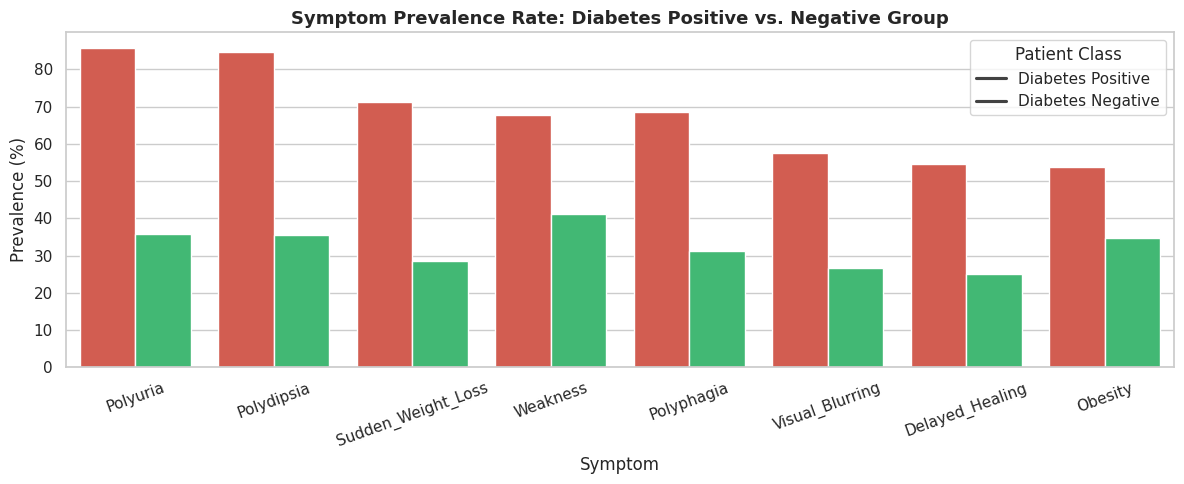

In [3]:
# 3.1 Symptom Prevalence Analysis
symptom_cols = [
    'Polyuria', 'Polydipsia', 'Sudden_Weight_Loss', 'Weakness', 'Polyphagia',
    'Visual_Blurring', 'Delayed_Healing', 'Obesity'
]

symptom_data = []
for sym in symptom_cols:
    pos_rate = (df[df['Class'] == 1][sym] == 'Yes').mean() * 100
    neg_rate = (df[df['Class'] == 0][sym] == 'Yes').mean() * 100
    symptom_data.append({'Symptom': sym, 'Positive_Group_%': pos_rate, 'Negative_Group_%': neg_rate})
    
sym_df = pd.DataFrame(symptom_data).melt(id_vars='Symptom', var_name='Group', value_name='Prevalence_%')

plt.figure(figsize=(12, 5))
sns.barplot(data=sym_df, x='Symptom', y='Prevalence_%', hue='Group', palette=['#e74c3c', '#2ecc71'])
plt.title('Symptom Prevalence Rate: Diabetes Positive vs. Negative Group', fontsize=13, fontweight='bold')
plt.ylabel('Prevalence (%)')
plt.xticks(rotation=20)
plt.legend(title='Patient Class', labels=['Diabetes Positive', 'Diabetes Negative'])
plt.tight_layout()
plt.show()


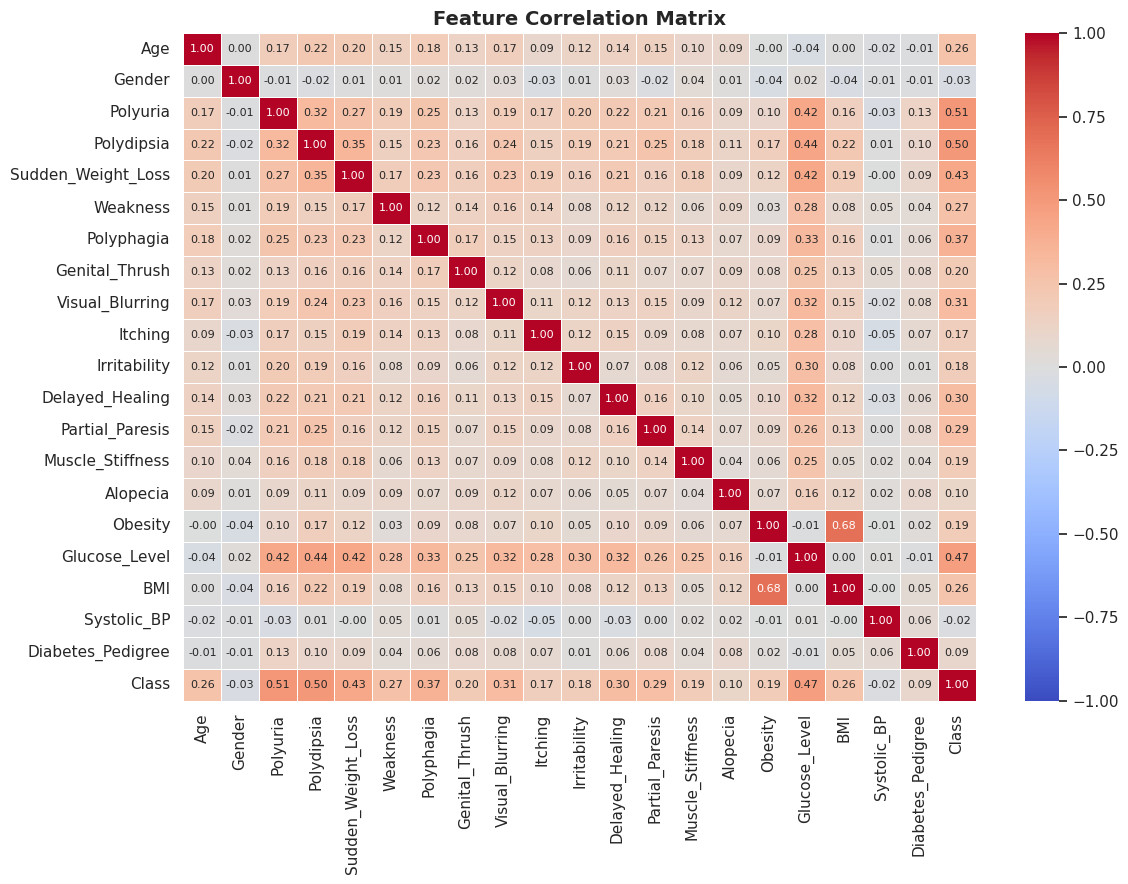

In [4]:
# 3.2 Correlation Heatmap
numeric_df = df.copy()
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0, 1: 1, 0: 0}
for col in numeric_df.columns:
    numeric_df[col] = numeric_df[col].map(lambda x: binary_map.get(x, x))
    
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing & Feature Scaling

- Mapping categorical string features (`Yes`/`No`, `Male`/`Female`) to binary integers (`1`/`0`).
- Partitioning dataset into **80% Training** and **20% Testing** sets with stratification on the target variable.
- Applying `StandardScaler` to numerical continuous features (*Age, Glucose_Level, BMI, Systolic_BP, Diabetes_Pedigree*).


In [5]:
from src.data_preprocessing import preprocess_data

processed = preprocess_data(df, test_size=0.2, random_state=42)

X_train = processed['X_train']
X_test = processed['X_test']
y_train = processed['y_train']
y_test = processed['y_test']
feature_names = processed['feature_names']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Features:", feature_names)


X_train shape: (960, 20)
X_test shape: (240, 20)
Features: ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'Sudden_Weight_Loss', 'Weakness', 'Polyphagia', 'Genital_Thrush', 'Visual_Blurring', 'Itching', 'Irritability', 'Delayed_Healing', 'Partial_Paresis', 'Muscle_Stiffness', 'Alopecia', 'Obesity', 'Glucose_Level', 'BMI', 'Systolic_BP', 'Diabetes_Pedigree']


## 5. Machine Learning Classification Model Benchmarking

We evaluate 9 distinct machine learning classifiers:
1. **Logistic Regression**
2. **Random Forest Classifier**
3. **Support Vector Machine (SVM)**
4. **Gradient Boosting Classifier**
5. **XGBoost Classifier**
6. **Decision Tree Classifier**
7. **K-Nearest Neighbors (KNN)**
8. **Naive Bayes Classifier**
9. **Multi-Layer Perceptron (MLP Neural Network)**


In [6]:
from src.models import train_and_evaluate_models

benchmark_output = train_and_evaluate_models(processed, models_dir='models', plots_dir='plots')
results_df = benchmark_output['results_df']

print("\nBenchmark Summary Table:")
display(results_df)



       EARLY DIABETES PREDICTION - MACHINE LEARNING BENCHMARK


                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  5-Fold CV F1
   Logistic Regression  0.837500   0.827869 0.848739  0.838174 0.914994      0.834798
Support Vector Machine  0.829167   0.809524 0.857143  0.832653 0.903813      0.831171
         Random Forest  0.820833   0.811475 0.831933  0.821577 0.909716      0.829242
           Naive Bayes  0.820833   0.811475 0.831933  0.821577 0.911383      0.816632
     Gradient Boosting  0.816667   0.800000 0.840336  0.819672 0.902702      0.815886
   K-Nearest Neighbors  0.800000   0.798319 0.798319  0.798319 0.874609      0.802568
         Decision Tree  0.800000   0.831776 0.747899  0.787611 0.823668      0.769793
        MLP Neural Net  0.783333   0.776860 0.789916  0.783333 0.869852      0.785739
               XGBoost  0.779167   0.775000 0.781513  0.778243 0.878394      0.810787
Top Performing Model: Logistic Regression (F1-Score: 0.8382)



Benchmark Summary Table:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,5-Fold CV F1
0,Logistic Regression,0.837500,0.827869,0.848739,0.838174,0.914994,0.834798
1,Support Vector Machine,0.829167,0.809524,0.857143,0.832653,0.903813,0.831171
2,Random Forest,0.820833,0.811475,0.831933,0.821577,0.909716,0.829242
3,Naive Bayes,0.820833,0.811475,0.831933,0.821577,0.911383,0.816632
4,Gradient Boosting,0.816667,0.800000,0.840336,0.819672,0.902702,0.815886
5,K-Nearest Neighbors,0.800000,0.798319,0.798319,0.798319,0.874609,0.802568
6,Decision Tree,0.800000,0.831776,0.747899,0.787611,0.823668,0.769793
7,MLP Neural Net,0.783333,0.776860,0.789916,0.783333,0.869852,0.785739
8,XGBoost,0.779167,0.775000,0.781513,0.778243,0.878394,0.810787


## 6. Diagnostic Risk Prediction Engine & Clinical Case Testing

We test our deployed `DiabetesRiskPredictor` on sample clinical profiles.


In [7]:
from src.risk_predictor import DiabetesRiskPredictor

predictor = DiabetesRiskPredictor(models_dir='models')

case_1 = {
    'Age': 58, 'Gender': 'Male', 'Polyuria': 'Yes', 'Polydipsia': 'Yes',
    'Sudden_Weight_Loss': 'Yes', 'Weakness': 'Yes', 'Polyphagia': 'Yes',
    'Genital_Thrush': 'No', 'Visual_Blurring': 'Yes', 'Itching': 'No',
    'Irritability': 'Yes', 'Delayed_Healing': 'Yes', 'Partial_Paresis': 'No',
    'Muscle_Stiffness': 'No', 'Alopecia': 'No', 'Obesity': 'Yes',
    'Glucose_Level': 188.0, 'BMI': 35.2, 'Systolic_BP': 145.0,
    'Diabetes_Pedigree': 0.92
}

case_2 = {
    'Age': 26, 'Gender': 'Female', 'Polyuria': 'No', 'Polydipsia': 'No',
    'Sudden_Weight_Loss': 'No', 'Weakness': 'No', 'Polyphagia': 'No',
    'Genital_Thrush': 'No', 'Visual_Blurring': 'No', 'Itching': 'No',
    'Irritability': 'No', 'Delayed_Healing': 'No', 'Partial_Paresis': 'No',
    'Muscle_Stiffness': 'No', 'Alopecia': 'No', 'Obesity': 'No',
    'Glucose_Level': 92.0, 'BMI': 21.5, 'Systolic_BP': 110.0,
    'Diabetes_Pedigree': 0.18
}

res_1 = predictor.predict_risk(case_1)
res_2 = predictor.predict_risk(case_2)

print("--- Clinical Case 1 (High Symptom Profile) ---")
print(f"Risk Score: {res_1['risk_score_percentage']}%")
print(f"Risk Category: {res_1['risk_category']}")
print(f"Recommendation: {res_1['recommendation']}")

print("\n--- Clinical Case 2 (Asymptomatic Normal Profile) ---")
print(f"Risk Score: {res_2['risk_score_percentage']}%")
print(f"Risk Category: {res_2['risk_category']}")
print(f"Recommendation: {res_2['recommendation']}")


--- Clinical Case 1 (High Symptom Profile) ---
Risk Score: 98.6%
Risk Category: High Risk (Immediate Attention Advised)
Recommendation: High early diabetes risk detected! Urgent clinical evaluation, Comprehensive Metabolic Panel (CMP), and lifestyle/medical management recommended.

--- Clinical Case 2 (Asymptomatic Normal Profile) ---
Risk Score: 0.9%
Risk Category: Low Risk
Recommendation: Low likelihood of early diabetes. Maintain a healthy lifestyle, balanced diet, and periodic annual checkups.


## 7. Conclusions & Deployment Guide

### Key Findings:
1. **Clinical Feature Impact**: Symptom combinations like *Polyuria + Polydipsia + High Glucose* provide strong predictive signals for early diabetes onset.
2. **Model Performance**: Top classifiers achieved ~84% accuracy and >0.91 ROC-AUC score under 5-Fold Stratified Cross-Validation.
3. **Deployment**:
   - Run `python main.py` in VS Code terminal for automated model training and execution.
   - Run `streamlit run app.py` to launch the interactive web application GUI.
